# Exploratory Data Analysis

1. Data Loading

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv('../data/raw/Traffic.csv')
df.head()
df.info()
print(df[['CarCount', 'BikeCount', 'BusCount', 'TruckCount']].describe())
print(df['Traffic Situation'].unique())
print(df.groupby('Traffic Situation')['CarCount'].mean().sort_values())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2976 entries, 0 to 2975
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Time               2976 non-null   object
 1   Date               2976 non-null   int64 
 2   Day of the week    2976 non-null   object
 3   CarCount           2976 non-null   int64 
 4   BikeCount          2976 non-null   int64 
 5   BusCount           2976 non-null   int64 
 6   TruckCount         2976 non-null   int64 
 7   Total              2976 non-null   int64 
 8   Traffic Situation  2976 non-null   object
dtypes: int64(6), object(3)
memory usage: 209.4+ KB
          CarCount    BikeCount     BusCount   TruckCount
count  2976.000000  2976.000000  2976.000000  2976.000000
mean     68.696573    14.917339    15.279570    15.324933
std      45.850693    12.847518    14.341986    10.603833
min       6.000000     0.000000     0.000000     0.000000
25%      19.000000     5.000000    

In [9]:
df.dtypes

Time                 object
Date                  int64
Day of the week      object
CarCount              int64
BikeCount             int64
BusCount              int64
TruckCount            int64
Total                 int64
Traffic Situation    object
dtype: object

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2976 entries, 0 to 2975
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Time               2976 non-null   object
 1   Date               2976 non-null   int64 
 2   Day of the week    2976 non-null   object
 3   CarCount           2976 non-null   int64 
 4   BikeCount          2976 non-null   int64 
 5   BusCount           2976 non-null   int64 
 6   TruckCount         2976 non-null   int64 
 7   Total              2976 non-null   int64 
 8   Traffic Situation  2976 non-null   object
dtypes: int64(6), object(3)
memory usage: 209.4+ KB


In [11]:
counts = df['Traffic Situation'].value_counts()
print("the distribution of traffic types:")
print(counts)

the distribution of traffic types:
Traffic Situation
normal    1669
heavy      682
high       321
low        304
Name: count, dtype: int64


2. Visualization of dataset

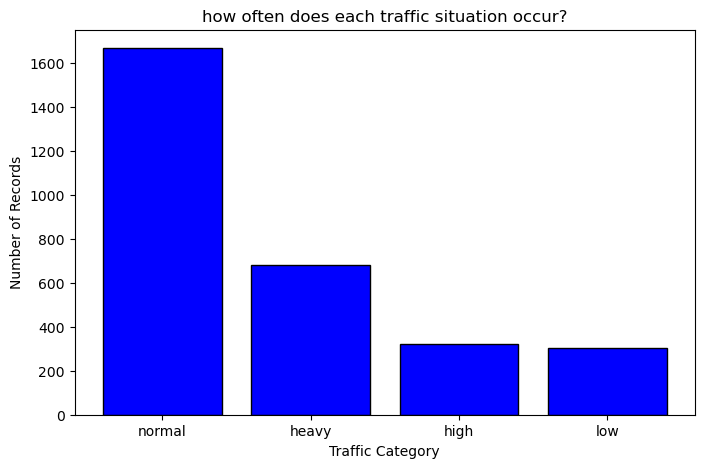

In [12]:
labels = counts.index
values = counts.values
plt.figure(figsize=(8, 5))
plt.bar(labels, values, color='blue', edgecolor='black')
plt.xlabel('Traffic Category')
plt.ylabel('Number of Records')
plt.title('how often does each traffic situation occur?')
plt.show()

3. Time patterns

In [13]:
df['Time'] = pd.to_datetime(df['Time'])
df['hour'] = df['Time'].dt.hour

C:\Users\nitaa\AppData\Local\Temp\ipykernel_7680\1211914487.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time'])


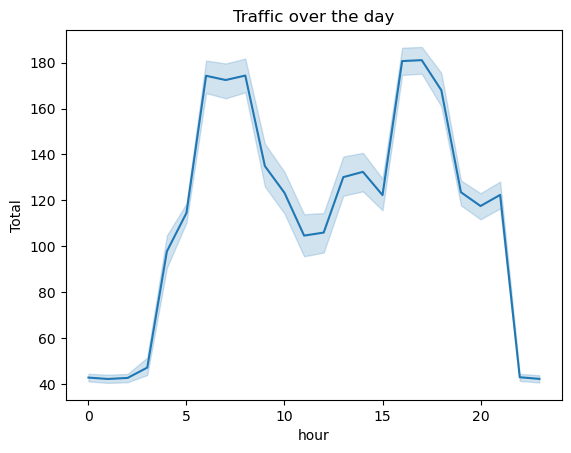

In [14]:
sns.lineplot(data=df, x='hour', y='Total')
plt.title("Traffic over the day")
plt.show()

Traffic peaks around 7-9 am and 16-19 pm, which likely corresponds to commuting hours.